**Student Name:** Yaron Winter

# Homework — NLP & Sequence Modeling

In this assignment, you will build end-to-end NLP pipelines and sequence models, combining classical text processing techniques with neural networks.

The homework is divided into two main parts:

1. Part 1 — Text Classification (AG News) :

    In this part, you will implement a full pipeline for text classification — from raw text to predictions.

    What you will learn:
    * How text is converted into tokens (subword tokenization)
    * How to learn word representations (embeddings)
    * How to use embeddings as input to neural networks
    * How to evaluate and analyze model performance

2. Part 2 — Character-Level Language Model (Char-RNN)

    In this part, you will build a sequence model that learns to generate text at the character level.

    What you will learn:
    * How sequence data is represented
    * How RNNs process sequential information
    * How generative models produce new sequences

**Submission Requirements (Important)**

Please make sure that:

1. All tasks are fully implemented
2. All questions are answered clearly
3. All notebook cells are executed
4. Do NOT submit notebooks with cleared outputs
5. Do NOT leave incomplete or placeholder code

Your submission should allow us to:

See outputs, results, and analysis

**Goal of the Assignment**

By completing this homework, you will:

* Build a complete NLP pipeline from scratch
* Understand how embeddings are learned and used
* Gain hands-on experience with neural networks for text
* Develop intuition for sequence modeling and generation

## Part 1- AG News with BPE + Word2Vec + MLP - 50 points

For this task we will use the [AG News Dataset](https://huggingface.co/datasets/sh0416/ag_news).

In [1]:
#Load the Data
from datasets import load_dataset

dataset = load_dataset("ag_news")
label_names = dataset["train"].features["label"].names

train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

print(train_df.shape, test_df.shape)
train_df.head()

(120000, 2) (7600, 2)


,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


### **Task 1 - Tokenization (BPE or WordPiece) - 10 points**

**Goal**

Convert raw text into tokens using subword tokenization.

Subword tokenization helps models handle:

* rare words

* unknown words

* morphological variation

          
|Example sentence | Word-level tokenization |Subword tokenization (BPE example) |
|----------------|:--------------------|:------------------|
|"unbelievable movie" |["unbelievable", "movie"]|   ["un", "believ", "able", "movie"]|



**Task**

Implement tokenization using Byte Pair Encoding (BPE) and WordPiece.


Read more here:

* [tokenizers](https://huggingface.co/docs/tokenizers/quicktour)


Train the tokenizer on the training corpus only.

Choose a vocabulary size (e.g., 10k tokens).

**Deliverables**

write 5 sentences and run through each tokenizer.
for example:

|Sentence|Tokens [BPE] | Tokens [WordPiece] |
|--------|:------|----------------------|
|this movie was unbelievable |["this", "movie", "was", "un", "believ", "able"]|["this", "movie", "was", "un", "##bel", "##ie", "##va", "##ble"]|

           

**Question**

What is the difference between BPE and WordPiece tokenization methods? When would you prefer to use each? Why both is considered better than wordlevel?

**Answer**

BPE and WordPiece differ in their merging rules: while BPE choose to merge pairs based on their frequecies, WordPiece considers the likelihood of the pairs as the merging criterion.

Though mostly, pairs with higher frequencies will have also higher likelihood, there might be differences for combinations that are specific and important for some domains, even if they are not especially frequent (e.g. "west bank" is not specically frequent, but it is a combination that might be important)

In [2]:
# Implementing BPE training
from tokenizers import Tokenizer
from tokenizers.models import BPE
bpe_tokenizer = Tokenizer(BPE(unk_token="[UNK]"))

from tokenizers.trainers import BpeTrainer
trainer = BpeTrainer(vocab_size=10000, special_tokens=["[UNK]", "[CLS]", "[SEP]", "[PAD]", "[MASK]"])

from tokenizers.pre_tokenizers import Whitespace
bpe_tokenizer.pre_tokenizer = Whitespace()

bpe_tokenizer.train_from_iterator(train_df.text.tolist(), trainer)
bpe_tokenizer.save("tokenizer_bpe.json")

In [3]:
# Implement WordPiece tokenizer
from tokenizers.models import WordPiece
wp_tokenizer = Tokenizer(WordPiece(unk_token="[UNK]"))

from tokenizers.trainers import WordPieceTrainer
trainer = WordPieceTrainer(vocab_size=10000, special_tokens=["[UNK]", "[CLS]", "[SEP]", "[PAD]", "[MASK]"])

wp_tokenizer.pre_tokenizer = Whitespace()

wp_tokenizer.train_from_iterator(train_df.text.tolist(), trainer)
wp_tokenizer.save("tokenizer_wordpiece.json")

In [4]:
# Present tokenizers performance on a few sentences
import pandas as pd

#sentences for example you may write your own
sentences = [
    "this movie was unbelievable",
    "the smartphone includes ultra-fast charging",
    "scientists discovered a new microorganism in antarctica",
    "the football player scored twice yesterday",
    "economic uncertainty affected international markets"
]

d = {
    "Sentence": sentences,
    "Tokens [BPE]": [bpe_tokenizer.encode(s).tokens for s in sentences],
    "Tokens [WordPiece]": [wp_tokenizer.encode(s).tokens for s in sentences],
}
df = pd.DataFrame(d)
df.head(5)

,Sentence,Tokens [BPE],Tokens [WordPiece]
0,this movie was unbelievable,"[this, movie, was, un, belie, v, able]","[this, movie, was, un, ##bel, ##ie, ##va, ##ble]"
1,the smartphone includes ultra-fast charging,"[the, smart, phone, includes, ult, ra, -, fast...","[the, smart, ##phone, includes, ul, ##tra, -, ..."
2,scientists discovered a new microorganism in a...,"[scientists, discovered, a, new, micro, organ,...","[scientists, discovered, a, new, mic, ##ro, ##..."
3,the football player scored twice yesterday,"[the, football, player, scored, twice, yesterday]","[the, football, player, scored, twice, yesterday]"
4,economic uncertainty affected international ma...,"[economic, uncertainty, affected, internationa...","[economic, uncertain, ##ty, affect, ##ed, inte..."


### **Task 2 — Train Word Embeddings (Word2Vec) - 10 points**

**Goal**

Train Word2Vec embeddings to represent BPE tokens as dense vectors.

Instead of representing words as large sparse vectors (Bag-of-Words), embeddings map words to a low-dimensional vector space.

|**Example**|**Embedding**|
|-----------|:------------|
|king       |[0.32, -0.12, 0.88, ...]|
|queen      |[0.30, -0.10, 0.91, ...]|


Words with similar meanings should have similar vectors.

**Task**

1. Train two Word2Vec models on the BPE-tokenized training sentences:

    * using Skip-gram

    * using CBOW

    * using diffrent embedding size [50,100,200]

    You may use the gensim library.

2. Run 3 examples embeddings and most similar words for example:

    * Embedding("movie") = [0.12, -0.44, 0.21, ...]

    * similar words (model.wv.most_similar("movie")): film, cinema, story

3. Then compare the two models and explain:

    * Which model performed better for this task
    * Why it may be better on this dataset
    * What embedding dimension you chose and why ?
    * What vocabulary size was actually learned, and why it may differ from the tokenizer vocabulary size

In [5]:
!pip install --upgrade gensim

In [6]:
from gensim.models import Word2Vec
import numpy as np

print("Tokenize the train texts")
tokenized_sentences = [
    bpe_tokenizer.encode(s).tokens for s in train_df.text
]


embedding_sizes = [50, 100, 200]

model_configs = [
    {"name": "CBOW", "sg": 0},        # sg=0 → CBOW
    {"name": "Skip-gram", "sg": 1},   # sg=1 → Skip-gram
]

models = {}


print("Train Models - Start")
for config in model_configs:
    for emb_dim in embedding_sizes:

        model_name = f"{config['name']}_{emb_dim}"

        print(f"\tworking on model: {model_name}")

        model = Word2Vec(
            sentences=tokenized_sentences,
            vector_size=emb_dim,
            window=5,
            min_count=2,
            sg=config["sg"],
            workers=4
        )

        models[model_name] = model
print("Train Models - End")

Tokenize the train texts
Train Models - Start
	working on model: CBOW_50
	working on model: CBOW_100
	working on model: CBOW_200
	working on model: Skip-gram_50
	working on model: Skip-gram_100
	working on model: Skip-gram_200
Train Models - End


In [7]:
# Test / Check the trained models
example_tokens = ["movie", "sport", "market"]

for model_name, model in models.items():
    print("\n" + "="*60)
    print(f"Model: {model_name}")

    for token in example_tokens:

        if token not in model.wv:
            continue

        print(f"\nToken: {token}")
        print(f"Token Vector: {model.wv[token][:10]}")
        print(f"Similar Words: {model.wv.most_similar(token)[:5]}")


Model: CBOW_50

Token: movie
Token Vector: [ 0.5545417  -1.3141677  -0.5691916  -0.12908007  1.1737692  -0.4664227
  0.97217155  0.0753362   1.4654979   1.3865031 ]
Similar Words: [('music', 0.7735083699226379), ('recording', 0.764480710029602), ('film', 0.762128472328186), ('swapping', 0.758636474609375), ('video', 0.7460392117500305)]

Token: sport
Token Vector: [-0.17922986 -1.1987722  -0.66395646 -0.7840936   1.0719427  -0.5137634
  0.50287455  0.09586596  0.66717726  0.8181734 ]
Similar Words: [('pool', 0.716840922832489), ('dream', 0.710922360420227), ('golf', 0.6951959133148193), ('competition', 0.6808851361274719), ('great', 0.6648869514465332)]

Token: market
Token Vector: [ 2.2152438   0.46944135 -0.94503284 -0.90365845  0.92497283 -1.9353597
  1.6272568  -0.2866537   1.736369    1.3841382 ]
Similar Words: [('business', 0.7953624129295349), ('sector', 0.7748164534568787), ('momentum', 0.7567057013511658), ('retailers', 0.7382694482803345), ('markets', 0.7350475192070007)]

M

write your answers

### **Task 3- MLP (Multi-Layer Perceptron) Architecture and Training - 10 points**

After tokenizing the text and training the embedding model, we are ready for the classification stage.

In this part, you will use the learned token embeddings as input features for an MLP (Multi-Layer Perceptron) model.

An MLP is a simple feed-forward neural network made of fully connected layers and non-linear activations. Unlike Word2Vec, which learns vector representations of tokens based on context, the MLP learns to map these representations to the target labels. In this assignment, the goal is to classify each news text into its correct category.

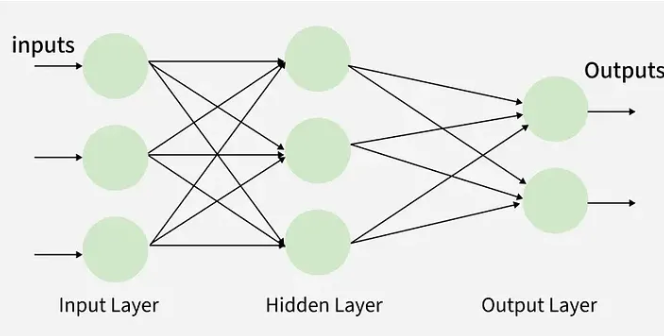

Because the each input training text contains a variable number of tokens, **you must first convert each tokenized sentence into a fixed-size vector representation**. One simple approach is to aggregate the token embeddings in the sentence, for example by taking the mean of all token embeddings. This sentence-level vector can then be passed into the MLP.

**Task**

Design and train an MLP model for text classification on the AG News dataset.

The model should take as input a sentence representation built from the learned BPE token embeddings, and output a prediction over the class labels.

**Requirements**

1. Convert each tokenized sentence into a fixed-length vector using the trained embeddings.
You may use:

    * mean pooling
    * sum pooling
    * If you choose a different method, explain it.

2. Design an MLP for the classification task.

Your model should include:
    * an input layer matching the embedding dimension
    * at least one hidden layer and up to 3
    * a non-linear activation function such as ReLU
    * an output layer with the correct number of classes

3. Train the model on the training set.

4. Clearly state your design choices, including:
    * the input representation
    * number of hidden layers
    * hidden dimension(s)
    * activation function
    * optimizer
    * learning rate
    * batch size
    * number of epochs

4. Briefly explain why an MLP can be used here, and what its limitation is compared to sequence-aware models such as RNNs.

The pipeline is:

Text → BPE tokens → token embeddings → pooling → MLP → class probabilities


In [8]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


# 1. Tokenize the texts using the trained BPE tokenizer
print("Tokenize the train and test sets")
train_tokens = [bpe_tokenizer.encode(s).tokens for s in train_df.text]
test_tokens  = [bpe_tokenizer.encode(s).tokens for s in test_df.text]


# 2. Choose your best trained Word2Vec model from task 2
w2v_model = models["Skip-gram_100"]
embedding_dim = w2v_model.wv.vector_size

print("Chosen embedding dimension:", embedding_dim)

# 3. Convert each sentence into ONE fixed-size vector
def sentence_to_vec(tokens, model, dim):
    vectors = []

    for tok in tokens:
        if tok in model.wv:
            vectors.append(model.wv[tok])

    # If no token in the sentence appears in the embedding vocabulary,
    # return a zero vector.
    if len(vectors) == 0:
        return np.zeros(dim, dtype=np.float32)

    # Use max pooling
    return np.max(np.array(vectors), axis=0)

# Build one fixed-size vector per text
print("Convert the sentences in the datasets to vectors")
X_train = np.array([sentence_to_vec(t, w2v_model, embedding_dim) for t in train_tokens], dtype=np.float32)
X_test  = np.array([sentence_to_vec(t, w2v_model, embedding_dim) for t in test_tokens], dtype=np.float32)

y_train = np.array(train_df["label"])
y_test  = np.array(test_df["label"])

print("X_train shape:", X_train.shape)   # expected: (num_train_samples, embedding_dim)
print("X_test shape:", X_test.shape)     # expected: (num_test_samples, embedding_dim)


# 4. Convert data into PyTorch Dataset / DataLoader
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

print(" Convert matrix from numpy to pytorce")
train_dataset = TextDataset(X_train, y_train)
test_dataset  = TextDataset(X_test, y_test)


# 5. Define the MLP model
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(in_features=input_dim, out_features=hidden_dim, bias=True),
            nn.Linear(in_features=hidden_dim, out_features=hidden_dim, bias=True),
            nn.Dropout(p=0.5),
            nn.Linear(in_features=hidden_dim, out_features=hidden_dim, bias=True),
            nn.Dropout(p=0.5),
            nn.ReLU(),
            nn.Linear(in_features=hidden_dim, out_features=num_classes),
            nn.ReLU(),
        )
    def forward(self, x):
        return self.model(x)
print("Preparations Done.")

Tokenize the train and test sets
Chosen embedding dimension: 100
Convert the sentences in the datasets to vectors
X_train shape: (120000, 100)
X_test shape: (7600, 100)
 Convert matrix from numpy to pytorce
Preparations Done.


In [9]:
# 6. Training setup
# Choose hidden_dim and justify your choice
model = MLP(input_dim=embedding_dim, hidden_dim=128, num_classes=train_df.label.unique().shape[0])
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adagrad(model.parameters(), lr=0.01)

# Try changing batch_size and explain your choice
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=256, shuffle=False)

EARLY_STOP_PATIENCE = 3

# 7. Training loop
epochs = 100
num_not_improved = 0
best_loss = None
for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch + 1}, Loss: {total_loss:.4f}")

    if best_loss is None or best_loss > total_loss:
        best_loss = total_loss
        num_not_improved = 0
    else:
        num_not_improved += 1

    if num_not_improved >= 3:
        print("Early Stop!!")
        break



Epoch 1, Loss: 376.3995
Epoch 2, Loss: 265.3627
Epoch 3, Loss: 257.8327
Epoch 4, Loss: 255.7372
Epoch 5, Loss: 253.4174
Epoch 6, Loss: 252.6800
Epoch 7, Loss: 251.9852
Epoch 8, Loss: 251.4763
Epoch 9, Loss: 250.8615
Epoch 10, Loss: 250.5164
Epoch 11, Loss: 249.3593
Epoch 12, Loss: 249.1528
Epoch 13, Loss: 249.1607
Epoch 14, Loss: 248.6642
Epoch 15, Loss: 248.8141
Epoch 16, Loss: 248.6068
Epoch 17, Loss: 248.1747
Epoch 18, Loss: 247.6972
Epoch 19, Loss: 247.8811
Epoch 20, Loss: 247.2901
Epoch 21, Loss: 247.2480
Epoch 22, Loss: 246.8087
Epoch 23, Loss: 247.1115
Epoch 24, Loss: 246.1993
Epoch 25, Loss: 246.2814
Epoch 26, Loss: 246.2397
Epoch 27, Loss: 246.4295
Early Stop!!


**My Choices:**

    - Input representation: Max Pooling 
        - it is usually used for implementing CNN, thus seems as a good starting point
    - Hidden Layer: 128
        - following a few trials
    - Activation Function: ReLU
    - Optimizer: AdaGrad
        - following a few trials + conclusions from the previous assignment
    - Learning Rate: 0.01
        - the default value + following trials
    - Batch Size: 256
        - following trials + laptop limitation
    - Epochs Number: 100
        - use early stop mechanism

**MLP:**

It can be used here due to the pooling, which enables representing
sentences of different length in a constant single dimension.
The main limitation of the pooling representaion is loosing the context,
the order of the words and the relations between them.
Besides, the pooling blurs the representation of the words themselves.

### **Task 4 - Evaluation and Error Analysis - 20 points**


After training your MLP model, evaluate its performance on the test set.

**Goals**
  * Measure classification performance using accuracy
  * Identify and analyze model errors
  * Better understand model limitations

**Requirements**
1. Compute test accuracy and confusion metrix
2. Print 3 examples where the model made incorrect predictions. For each error, display:
    * Original text
    * True label
    * Predicted label
3. Do you see a pattern or can point on where the model fails?
3. Suggest one method to analyze which parts of the input text influenced the model's prediction.
You do not need to implement it — only explain the idea.

In [10]:
# Evaluation - predict labels for the test set.
ground_truth = []
predictions = []
for X_batch, y_batch in test_loader:
    logits = model(X_batch)
    ground_truth.extend(y_batch.tolist())
    predictions.extend(torch.argmax(logits.detach(), dim=1).tolist())
print("Done Prediction")

Done Prediction



Accuracy: 0.803




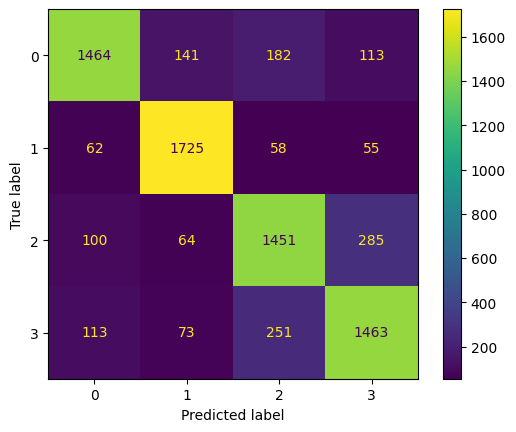

In [11]:
# Present results
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

res = [int(x==y) for x,y in zip(ground_truth, predictions)]
accuracy = sum(res) / len(predictions)
print(f"\nAccuracy: {accuracy:.3f}\n\n")

cm = confusion_matrix(y_test, predictions, labels=[0, 1, 2, 3])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3])
disp.plot()
plt.show()

In [19]:
# Present Failures

# Find the first three prediction errors.
error_index = []
for i in range(len(res)):
    if len(error_index) >= 5:
        break
        
    if res[i] == 1:
        continue
    error_index.append(i)
print(f"Errors: {error_index}")

i = 0
for e in error_index[1:4]:
    i += 1
    print(f"Error {i}:\ntext={test_df.loc[e, "text"]},\ntrue label={ground_truth[e]},\npredicton={predictions[e]}\n")

Errors: [1, 2, 3, 5, 7]
Error 1:
text=Ky. Company Wins Grant to Study Peptides (AP) AP - A company founded by a chemistry researcher at the University of Louisville won a grant to develop a method of producing better peptides, which are short chains of amino acids, the building blocks of proteins.,
true label=3,
predicton=1

Error 2:
text=Prediction Unit Helps Forecast Wildfires (AP) AP - It's barely dawn when Mike Fitzpatrick starts his shift with a blur of colorful maps, figures and endless charts, but already he knows what the day will bring. Lightning will strike in places he expects. Winds will pick up, moist places will dry and flames will roar.,
true label=3,
predicton=1

Error 3:
text=Open Letter Against British Copyright Indoctrination in Schools The British Department for Education and Skills (DfES) recently launched a "Music Manifesto" campaign, with the ostensible intention of educating the next generation of British musicians. Unfortunately, they also teamed up with the mu

In [20]:
# Examples for scientific words tokenization.
print(f"peptides: {bpe_tokenizer.encode("peptides").tokens}")
print(f"chemistry: {bpe_tokenizer.encode("chemistry").tokens}")
print(f"flames: {bpe_tokenizer.encode("flames").tokens}")
print(f"Wildfires: {bpe_tokenizer.encode("Wildfires").tokens}")
print(f"indoctrinated: {bpe_tokenizer.encode("indoctrinated").tokens}")

peptides: ['pe', 'pt', 'ides']
chemistry: ['chem', 'ist', 'ry']
flames: ['fl', 'ames']
Wildfires: ['Wild', 'fires']
indoctrinated: ['ind', 'o', 'ct', 'r', 'inated']


**Error Pattern**

I could not recognize any evident pattern for the failures.

At first, I thought that there might be a correlation between the length of the text
to the tendency of the model to fail. But a quick check proved that there is no correlation
at all, between the text length to failures.

Then I noticed that all three error examples come from scientific texts, and contain many scientific
words (e.g. chemistry, peptides, Ganymede, etc.).

These words are not frequent in the text, and thus are broken into few tokens, which may blur
their meaning/weight significantly.

**Method for Analysis and Improvement**

First, I would check if there is indeed a strong correlation between important words that are
broken into several tokens - as explained above - to the tendency of the model to fail.
If there is, it may be repaired by recognizing such words in the text (e.g. by tf-idf, likelihood, etc.)
and make sure that they will not be broken into several tokens.

Another simple test would be to eliminate 'function words' from the representation of a sentence.

'Function words', in this context, refer to words that are very frequent, but are not distinctive and
helpful, in this classication task.

Such words can be detected throuh tf-idf, for example. Such words (e.g. it, to, etc.) may be crucial
when context is considered, but in our case, where the context is compeltely ignored, they mainly
blur the weights of more significant words/tokens.
So we may try to skip them, when collecting the vectors for representing a sentence, in a similar
way to how we skip unknown words/tokens.

And of course, there is also the alternative of further hyper parameters tuning (e.g. learning rate,
batch size, hidden layer size, etc.)

## Part 2- Char-RNN Model - 50 points

Similarly to word-level language model, char-level RNN model processes one token at a time, but in this case a token represents a single character.


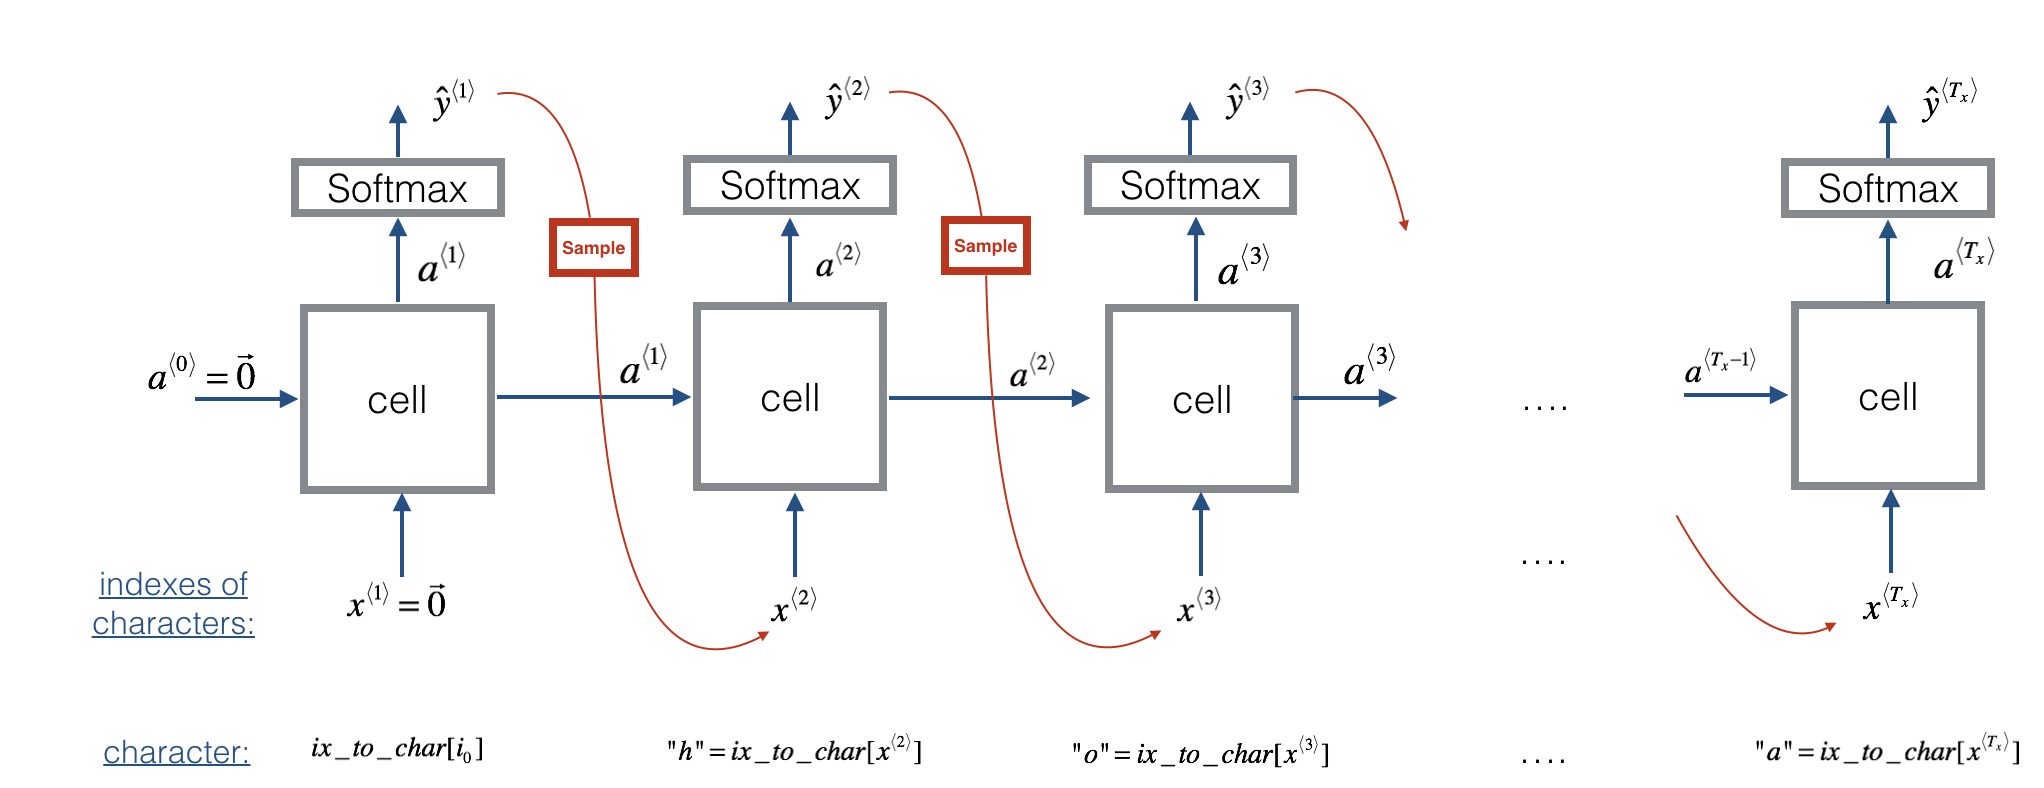

In this part you will build a model that generating dinosaur names, the dataset can be found [here](https://gist.github.com/judahsemi/210d42e0410c122aa0e437861c46cf94).

This a txt file with dinosaur names. Your mission is to get creative and create new names of unknown dinosaurs.

### **Task 1 - Build a PyTorch Dataset for RNN Training - 10 points**

**Goal**

Create a custom PyTorch Dataset for training a character-level RNN model on a dataset of names.

**Input**

Your dataset should be initialized with:

1. seq_len - the length of each sequence
2. data - path to txt file or a list of names

**Requierments**
1. Preprocess the data
      * Add a start token '<' at the beginning of each name
      * Add an end token '>' at the end of each name
  
    Example: "anna" → "`<anna>`"
    
    Concatenate all processed names into one long string

2. Build vocabulary
      * Extract all unique characters from the data (including '<' and '>')
      * Create:
        - token_to_id mapping
        - id_to_token mapping

      * Store them in the dataset as:
        - self.vocab
        - self.token_to_id
        - self.id_to_token

3. Create sequences
      * Split the full text into sequences of length seq_len
      * Each dataset item should be based on a sliding window over the text.

4. Define dataset items
      * Each item should return a pair of tensors:

      * Input tensor (x) -
        sequence of character IDs of length seq_len
      * Target tensor (y) -
        same sequence shifted by one character

Example:
    
    Text:    "<anna>"
    seq_len: 4

    x: "<ann"
    y: "anna"

5. Implement Dataset methods

      * Your dataset class must implement:

        - __len__() → returns the number of sequences
        - __getitem__(idx) → returns (x, y) as PyTorch tensors


In [12]:
import torch

class DinosDataset(torch.utils.data.Dataset):
    def __init__(self, data, seq_len):
        self.seq_len = seq_len

        # Load the names and concatenate them into a single string.
        with open(data, "r", encoding="utf-8") as f:
            names = ["<" + x.strip() + ">" for x in f.readlines()]
        self.text = "".join(names)

        # Build vocabulary
        self.vocab = list(set([x for x in self.text]))
        self.vocab.sort()
        self.token_to_id = {self.vocab[i]:i for i in range(len(self.vocab))}
        self.id_to_token = {y:x for x,y in self.token_to_id.items()}

        # Convert text to list of ids
        self.data = [self.token_to_id[x] for x in self.text]

    def __len__(self):
        return (len(self.data) - self.seq_len - 1)

    def __getitem__(self, idx):
        x = self.data[idx:idx + self.seq_len]
        y = self.data[idx + 1:idx + self.seq_len + 1]
        return torch.tensor(x), torch.tensor(y)

Split your dataset to get train and validation PyTorch datasets using method from `datasets` library.:

In [13]:
from torch.utils.data import dataset, DataLoader
dinos_ds = DinosDataset(data="dinos.txt", seq_len=10)
print(f"dinos dataset size: {len(dinos_ds)}")
train_size = int(0.8 * len(dinos_ds))
test_size = len(dinos_ds) - train_size
train_ds, test_ds = dataset.random_split(dinos_ds, [train_size, test_size])
print(f"train: {len(train_ds)}")
print(f"test: {len(test_ds)}")

dinos dataset size: 21453
train: 17162
test: 4291


Prepare PyTorch Dataloaders for train and validation datasetssets with fixed batch_size.

In [14]:
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

In [15]:
# example of a single batch from dataloader
batch = next(iter(train_loader))
batch[0]

tensor([[ 0,  3, 45, 42, 41, 47, 42, 46, 28, 48],
        [37, 28, 46, 28, 48, 45, 48, 46,  1,  0],
        [46, 36, 48, 46,  1,  0, 21, 35, 42, 47],
        [ 0, 20, 36, 41, 42, 45, 41, 36, 47, 35],
        [48, 45, 48, 46,  1,  0,  9, 52, 43, 28],
        [ 1,  0, 21, 32, 51, 28, 46, 32, 47, 32],
        [12, 28, 47, 46, 48, 52, 28, 40, 28, 46],
        [46, 28, 48, 45, 48, 46,  1,  0,  2, 41],
        [46, 38, 48, 46,  1,  0, 12, 36, 41, 41],
        [48, 45, 42, 36, 31, 32, 46,  1,  0,  4],
        [42, 41, 34,  1,  0, 27, 35, 42, 41, 34],
        [42, 46, 28, 48, 45, 48, 46,  1,  0, 20],
        [45,  1,  0,  2, 45, 30, 35, 28, 32, 42],
        [41, 48, 46,  1,  0, 13, 32, 28, 32, 39],
        [48, 46,  1,  0, 15, 34, 32, 51, 36, 46],
        [28, 41, 40, 28, 41, 46, 28, 48, 45, 48],
        [47, 36, 47, 28, 41,  1,  0, 17, 28, 39],
        [48, 45, 48, 46,  1,  0, 15, 52, 42, 45],
        [36, 41, 48, 46, 42, 41, 28, 46, 48, 46],
        [ 0, 12, 48, 41, 29, 28, 45, 45, 28, 46],


### **Task 2 - Implement one-hot encoding - 5 points**

Instead of embedding layer, we will use one-hot encoding to pass input characters to LSTM layers of the network. It means that each character would be represented with a vector of dimension equal to the size of vocabulary, with a single non-zero element (the element equals 1) at the position of the character's index.

```
char = 'b'
id[char] = 2
one_hot = [0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
```

Write function `one_hot_encode` to implement one-hot encoding for a character index vector. It should take array containing sequences of character ids and vocab_size as arguments and return one-hot encoded numpy array of shape `(initial_array_shape, vocab_size)`.

In [16]:
# There is no need to define the function one_hot_encode,
# as it consists of a single line, which can be called
# directly.
from torch.nn import functional as F
encoded = F.one_hot(batch[0], len(dinos_ds.vocab))
print(encoded.shape)
encoded

torch.Size([32, 10, 54])


tensor([[[1, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 1, 0,  ..., 0, 0, 0],
         [1, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        ...,

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0,

### **Task 3 - Model - 5 points**

Here's a character level LSTM model. We don't use Embedding layer as it will be replaced with one-hot encoding during training.

In [17]:
from torch import nn
class CharRNN(nn.Module):

    def __init__(self, vocab_size, n_steps=100, n_hidden=256, n_layers=2,
                               drop_prob=0.5, lr=0.001):
        super().__init__()
        self.drop_prob = drop_prob
        self.n_layers = n_layers
        self.n_hidden = n_hidden
        self.lr = lr
        self.vocab_size = vocab_size

        self.lstm = nn.LSTM(self.vocab_size, n_hidden, n_layers,
                            dropout=drop_prob, batch_first=True)

        self.dropout = nn.Dropout(drop_prob)

        self.fc = nn.Linear(n_hidden, self.vocab_size)


    def forward(self, x, hc):
        x, (h, c) = self.lstm(x, hc)
        x = self.dropout(x)

        # output of LSTM layer has shape [batch_size, sequence_length, hidden_dimension]
        # for fully connected layer we need to transform the output to the shape [batch_size * sequence_length, hidden_dimension]
        x = x.contiguous().view(x.size()[0]*x.size()[1], self.n_hidden)
        x = self.fc(x)

        return x, (h, c)

    def init_hidden(self, batch_size, device):
        ''' Initializes hidden state '''

        weight = next(self.parameters()).data
        return (weight.new(self.n_layers, batch_size, self.n_hidden).zero_().to(device),
                weight.new(self.n_layers, batch_size, self.n_hidden).zero_().to(device))


Run one pass through the model to get predictions for a single batch.

For a fixed batch:
- apply one-hot encoding,
- run `forward` method of the model step by step, and print out the output of each layer and its dimensions,
- apply softmax to the output of forward pass to get probability distributions for a batch.

In [18]:
print("Step 1: Apply LSTM on the batch:\n")
rnn = CharRNN(vocab_size=len(dinos_ds.vocab))
x, (h, c) = rnn.lstm(encoded.to(torch.float32), rnn.init_hidden(32, 'cpu'))
print(f"x={x.shape}\n\n{x[:3,:5,:5]}\n\nh={h.shape}\n\n{h[:,:5,:5]}\n\nc={c.shape}\n\n{c[:,:5,:5]}")

Step 1: Apply LSTM on the batch:

x=torch.Size([32, 10, 256])

tensor([[[ 0.0131, -0.0079,  0.0043, -0.0115,  0.0047],
         [ 0.0231, -0.0019,  0.0033, -0.0146,  0.0033],
         [ 0.0237,  0.0016,  0.0044, -0.0105,  0.0072],
         [ 0.0358, -0.0004,  0.0087, -0.0019, -0.0001],
         [ 0.0425,  0.0018,  0.0155, -0.0056, -0.0015]],

        [[ 0.0115, -0.0049,  0.0048, -0.0105, -0.0025],
         [ 0.0219, -0.0052,  0.0099, -0.0126,  0.0042],
         [ 0.0199, -0.0013,  0.0158, -0.0104,  0.0053],
         [ 0.0307,  0.0062,  0.0152, -0.0102,  0.0058],
         [ 0.0281,  0.0082,  0.0203, -0.0142,  0.0121]],

        [[ 0.0120, -0.0032, -0.0015, -0.0098,  0.0011],
         [ 0.0257,  0.0013,  0.0059, -0.0086, -0.0022],
         [ 0.0230, -0.0027,  0.0064, -0.0107,  0.0009],
         [ 0.0250,  0.0021,  0.0083, -0.0151,  0.0135],
         [ 0.0303,  0.0058,  0.0185, -0.0047,  0.0094]]],
       grad_fn=<SliceBackward0>)

h=torch.Size([2, 32, 256])

tensor([[[ 0.0116,  0.0002, -

In [19]:
print("Step 2: Dropout:\n")
x = rnn.dropout(x)
print(f"x={x.shape}\n\n{x[:3,:5,:5]}")

Step 2: Dropout:

x=torch.Size([32, 10, 256])

tensor([[[ 0.0000, -0.0159,  0.0000, -0.0000,  0.0000],
         [ 0.0462, -0.0000,  0.0067, -0.0292,  0.0067],
         [ 0.0000,  0.0000,  0.0088, -0.0209,  0.0144],
         [ 0.0716, -0.0000,  0.0174, -0.0039, -0.0000],
         [ 0.0850,  0.0000,  0.0000, -0.0000, -0.0000]],

        [[ 0.0000, -0.0000,  0.0095, -0.0209, -0.0000],
         [ 0.0000, -0.0000,  0.0000, -0.0252,  0.0000],
         [ 0.0000, -0.0026,  0.0316, -0.0000,  0.0106],
         [ 0.0615,  0.0124,  0.0305, -0.0204,  0.0116],
         [ 0.0000,  0.0000,  0.0407, -0.0285,  0.0000]],

        [[ 0.0000, -0.0000, -0.0000, -0.0195,  0.0000],
         [ 0.0000,  0.0000,  0.0000, -0.0000, -0.0044],
         [ 0.0000, -0.0054,  0.0129, -0.0000,  0.0000],
         [ 0.0500,  0.0000,  0.0165, -0.0303,  0.0270],
         [ 0.0000,  0.0117,  0.0000, -0.0000,  0.0000]]],
       grad_fn=<SliceBackward0>)


In [20]:
print("Step 3: Apply contiguous:\n")
x = x.contiguous().view(x.size()[0]*x.size()[1], rnn.n_hidden)
print(f"x={x.shape}\n\n{x[:5,:5]}")

Step 3: Apply contiguous:

x=torch.Size([320, 256])

tensor([[ 0.0000, -0.0159,  0.0000, -0.0000,  0.0000],
        [ 0.0462, -0.0000,  0.0067, -0.0292,  0.0067],
        [ 0.0000,  0.0000,  0.0088, -0.0209,  0.0144],
        [ 0.0716, -0.0000,  0.0174, -0.0039, -0.0000],
        [ 0.0850,  0.0000,  0.0000, -0.0000, -0.0000]],
       grad_fn=<SliceBackward0>)


In [21]:
print("Step 4: Apply prediction:\n")
x = rnn.fc(x)
print(f"x={x.shape}\n\n{x[:5,:5]}")

Step 4: Apply prediction:

x=torch.Size([320, 54])

tensor([[ 0.0299, -0.0335, -0.0168, -0.0019,  0.0487],
        [ 0.0262, -0.0336, -0.0219, -0.0139,  0.0599],
        [ 0.0389, -0.0453, -0.0270,  0.0081,  0.0556],
        [ 0.0270, -0.0259, -0.0167, -0.0067,  0.0346],
        [ 0.0320, -0.0465, -0.0365,  0.0102,  0.0276]],
       grad_fn=<SliceBackward0>)


In [22]:
print("Step 5: Softmax:\n")
predictions = nn.Softmax(dim=1)(x)
print(f"predictions={predictions.shape}\n\n{predictions[:5,:5]}")

Step 5: Softmax:

predictions=torch.Size([320, 54])

tensor([[0.0191, 0.0179, 0.0182, 0.0185, 0.0194],
        [0.0190, 0.0179, 0.0181, 0.0182, 0.0196],
        [0.0192, 0.0177, 0.0180, 0.0186, 0.0195],
        [0.0189, 0.0180, 0.0181, 0.0183, 0.0191],
        [0.0191, 0.0176, 0.0178, 0.0186, 0.0190]], grad_fn=<SliceBackward0>)


### **Task 4 - Training - 10 points**

Now we can define a training function. Note that it calls `one_hot_encode` function that you've implemented in the previous task.

In [23]:
def train(net, train_dataloader, val_dataloader, epochs=10, batch_size=64, n_steps=10, lr=0.001, clip=5,
          device='cpu', print_every=10):
    '''
        net: CharRNN model
        train_dataloader: train dataloader
        val_dataloader: validation dataloaderur submission should allow
        epochs: number of epochs
        batch_size: batch size
        n_steps: number of character steps (sequence length defined in dataset)
        lr: learning rate
        clip: gradient clipping
        device: device_type (GPU or CPU)
        print_every: number of steps for printing loss
    '''

    net.train()
    opt = torch.optim.Adam(net.parameters(), lr=lr)

    criterion = nn.CrossEntropyLoss().to(device)

    net.to(device)

    counter = 0
    n_chars = net.vocab_size

    for e in range(epochs):

        # Make sure that we are in train mode,
        # in the beginning of each iteration.
        net.train()
        h = net.init_hidden(batch_size, device)

        for x, targets in train_dataloader:

            counter += 1

            # Apply one hot directly - no need to convert from numpy.
            inputs = F.one_hot(x, n_chars).to(torch.float32)

            inputs.to(device)
            targets.to(device)

            # create new variables for the hidden state not to backprop through the entire training history
            if x.shape[0] == batch_size:
                h = tuple([each.data for each in h])
            else:
                h = net.init_hidden(x.shape[0], device)

            net.zero_grad()
            output, h = net.forward(inputs, h)
            loss = criterion(output, targets.view(x.shape[0]*n_steps))

            loss.backward()

            # clip_grad_norm helps to prevent the exploding gradients in RNN
            nn.utils.clip_grad_norm_(net.parameters(), clip)

            opt.step()

            if counter % print_every == 0:
                net.eval()
                with torch.no_grad():
                    val_h = net.init_hidden(batch_size, device)
                val_losses = []

                for x, y in val_dataloader:
                    x = F.one_hot(x, n_chars).to(torch.float32)

                    if x.shape[0] == batch_size:
                        val_h = tuple([each.data for each in val_h])
                    else:
                        val_h = net.init_hidden(x.shape[0], device)
                        
                    inputs, targets = x, y
                    inputs.to(device)
                    targets.to(device)

                    with torch.no_grad():
                        output, val_h = net.forward(inputs, val_h)

                    val_loss = criterion(output, targets.view(x.shape[0]*n_steps))
                    val_losses.append(val_loss.item())

                net.train()
                print("Epoch: {}/{}...".format(e+1, epochs),
                      "Step: {}...".format(counter),
                      "Loss: {:.4f}...".format(loss.item()),
                      "Val Loss: {:.4f}".format(torch.mean(torch.tensor(val_losses)).item()))


Initialize the model and run training for fixed number of epochs.

In [24]:
batch_size = 64
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
rnn = CharRNN(vocab_size=len(dinos_ds.vocab))
train(net=rnn,
      train_dataloader=train_loader,
      val_dataloader=test_loader,
      epochs=10,
      n_steps=dinos_ds.seq_len,
      batch_size=batch_size,
      print_every=100)

Epoch: 1/10... Step: 100... Loss: 3.0157... Val Loss: 2.9547
Epoch: 1/10... Step: 200... Loss: 2.1339... Val Loss: 2.0840
Epoch: 2/10... Step: 300... Loss: 1.8826... Val Loss: 1.9090
Epoch: 2/10... Step: 400... Loss: 1.9052... Val Loss: 1.8309
Epoch: 2/10... Step: 500... Loss: 1.8744... Val Loss: 1.7728
Epoch: 3/10... Step: 600... Loss: 1.8964... Val Loss: 1.7391
Epoch: 3/10... Step: 700... Loss: 1.8848... Val Loss: 1.7093
Epoch: 3/10... Step: 800... Loss: 1.6952... Val Loss: 1.6819
Epoch: 4/10... Step: 900... Loss: 1.7219... Val Loss: 1.6587
Epoch: 4/10... Step: 1000... Loss: 1.7994... Val Loss: 1.6364
Epoch: 5/10... Step: 1100... Loss: 1.6117... Val Loss: 1.6168
Epoch: 5/10... Step: 1200... Loss: 1.6997... Val Loss: 1.5975
Epoch: 5/10... Step: 1300... Loss: 1.6367... Val Loss: 1.5785
Epoch: 6/10... Step: 1400... Loss: 1.7012... Val Loss: 1.5627
Epoch: 6/10... Step: 1500... Loss: 1.6730... Val Loss: 1.5472
Epoch: 6/10... Step: 1600... Loss: 1.5371... Val Loss: 1.5305
Epoch: 7/10... St

In [25]:
print(rnn)

CharRNN(
  (lstm): LSTM(54, 256, num_layers=2, batch_first=True, dropout=0.5)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=54, bias=True)
)


### **Task 5 - Generating Name - 5 points**

Now we can generate a dinosaur name using the trained model.

In [26]:
# The predict function is modified for supporting all
# three generation methods - random sampling, top_k, and temperature -
# by a single function.
# Notice that when temperature=1.0 and top_k=len(vocab), the generation
# is reduced to random sampling.
# So based on configuration, this function will test all three methods.
def predict(char, model, id_to_token, token_to_id, h=None, top_k=5, temperature=1.0):
    '''
    Predict the next character for the current character char
    (returns the predicted character and the hidden state).
    '''
    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
    model.to(device)

    if h is None:
        with torch.no_grad():
            h = model.init_hidden(1, device)

    x = torch.tensor(token_to_id[char]).view(-1,1)
    inputs = F.one_hot(x, len(token_to_id)).to(torch.float32)
    inputs.to(device)

    h = tuple([each.data for each in h])

    with torch.no_grad():
        out, h = model.forward(inputs, h)

    out = ((out / temperature) if temperature > 0 else out)
    p = F.softmax(out, dim=1).data
    p = p.cpu()

    p = p.numpy().squeeze()
    sorted_inds = np.flip(np.argsort(p))
    sorted_vals = np.flip(np.sort(p))
    
    top_ch = np.arange(top_k)
    char_ind = np.random.choice(top_ch, p=sorted_vals[:top_k]/sorted_vals[:top_k].sum())
            
    return id_to_token[sorted_inds[char_ind]], h

In [27]:
def sample(model, size, id_to_token, token_to_id, prefix='<', top_k=5, temperature=1.0):
    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
    model.to(device)
    model.eval()

    chars = [ch for ch in prefix]

    with torch.no_grad():
        h = model.init_hidden(1, device)

    for ch in prefix:
        char, h = predict(ch, model, id_to_token, token_to_id, h, top_k=top_k, temperature=temperature)

    chars.append(char)

    for i in range(size):
        char, h = predict(chars[-1], model, id_to_token, token_to_id, h, top_k=top_k, temperature=temperature)
        chars.append(char)
        if char == '>':
            break

    return ''.join(chars)

Try to generate names using different prefixes (also counts as the part of the task!).

In [30]:
PREFIXES = ["<", "<Din", "<Adas", "<Ya", "<Bu"]
SIZES = [20, 20, 20, 11, 10]

id_to_token = dinos_ds.id_to_token
token_to_id = dinos_ds.token_to_id

def display_generation_results(model, top_k: int, temperature: float, id_to_token: dict, token_to_id: dict):
    for i in range(len(PREFIXES)):
        pref = PREFIXES[i]
        s = SIZES[i]
        print(f"Attempt {i}: prefix={pref}, size={s}")
        res = sample(model, size=s, id_to_token=id_to_token, token_to_id=token_to_id, prefix=pref, top_k=top_k, temperature=t)
        print(f"Result: {res}\n\n")

In [32]:
top_k = len(dinos_ds.vocab)
t = 1.0

print(f"Random Sampling Test: top_k={top_k}, temperature={t}\n")
display_generation_results(model=rnn, top_k=top_k, temperature=t, id_to_token=id_to_token, token_to_id=token_to_id)

Random Sampling Test: top_k=54, temperature=1.0

Attempt 0: prefix=<, size=20
Result: <Yiuquijiceratops>


Attempt 1: prefix=<Din, size=20
Result: <Dingthade>


Attempt 2: prefix=<Adas, size=20
Result: <Adasaurus>


Attempt 3: prefix=<Ya, size=11
Result: <Yabroraptor>


Attempt 4: prefix=<Bu, size=10
Result: <Buatoocurus>




### **Task 6 - Sampling - 15 points**

Basic strategy for choosing next token after building probability distribution is **greedy search**. According to this approach we simply choose a token with the highest probability.
Here in `predict` function we applied **random sampling** to randomly choose the next token for prediction based on probability distribution obtained from softmax. Let's try out different generation strategies.

**Top-k sampling**

In random sampling we choose the next character using probability distribution over all characters of the vocabulary. We can limit the model to sample next token only among $k$ most probable tokens.

![top_k_sampling](https://raw.githubusercontent.com/patrickvonplaten/scientific_images/master/top_k_sampling.png)



**Temperature**

We can try to affect the level of variation for our model generation.
Adding temperature parameter allows to smooth probability distribution so with higher temperature rare characters would appear more often.
This effect could be accomplished if we divide the logits by a temperature value.  Check [the link](https://lukesalamone.github.io/posts/what-is-temperature/) for more details.

**Task**

1. Modify functions predict and sample adding parameter top_k to consider  k  most probable characters. **Compare the results of generation using this approach to random sampling.**

2. Modify predict and sample functions for top-k sampling using parameter temperature.**Check the results of generation using sampling with different temperature values.**

Breifly write your insights.

In [37]:
top_k = 7
t = 1.0

print(f"Top K Selection Test: top_k={top_k}, temperature={t}\n")
display_generation_results(model=rnn, top_k=top_k, temperature=t, id_to_token=id_to_token, token_to_id=token_to_id)

Top K Selection Test: top_k=7, temperature=1.0

Attempt 0: prefix=<, size=20
Result: <Miasaurus>


Attempt 1: prefix=<Din, size=20
Result: <Dinosaurus>


Attempt 2: prefix=<Adas, size=20
Result: <Adasaurus>


Attempt 3: prefix=<Ya, size=11
Result: <Yangaurus>


Attempt 4: prefix=<Bu, size=10
Result: <Burus>




**Top K Results:**

Indeed, the top k results seem, in a first and view, better than the results obtained with random sampling.
The prefix '<Din', for example, was completed perfectly, while in random sampling it was totally mistaken.

Also the other words make more sense than the words generated by random sampling.

In [38]:
top_k = 7
t = 0.5

print(f"Top K + Temperature Test, low temperature: top_k={top_k}, temperature={t}\n")
display_generation_results(model=rnn, top_k=top_k, temperature=t, id_to_token=id_to_token, token_to_id=token_to_id)

Top K + Temperature Test, low temperature: top_k=7, temperature=0.5

Attempt 0: prefix=<, size=20
Result: <Anchisaurus>


Attempt 1: prefix=<Din, size=20
Result: <Dinosaurus>


Attempt 2: prefix=<Adas, size=20
Result: <Adasuchus>


Attempt 3: prefix=<Ya, size=11
Result: <Yangosaurus>


Attempt 4: prefix=<Bu, size=10
Result: <Burus>




In [39]:
top_k = 7
t = 1.5

print(f"Top K + Temperature Test, high temperature: top_k={top_k}, temperature={t}\n")
display_generation_results(model=rnn, top_k=top_k, temperature=t, id_to_token=id_to_token, token_to_id=token_to_id)

Top K + Temperature Test, high temperature: top_k=7, temperature=1.5

Attempt 0: prefix=<, size=20
Result: <Mosulicus>


Attempt 1: prefix=<Din, size=20
Result: <Dinisos>


Attempt 2: prefix=<Adas, size=20
Result: <Adasauravansaurus>


Attempt 3: prefix=<Ya, size=11
Result: <Yangasaurus>


Attempt 4: prefix=<Bu, size=10
Result: <Bulacinopandr




**Discussion**

Above, in the top_k selection test, we saw that the top_k induce more stable and reasonable results,
than the results that were generated by the random sampling.

When adding temperature to the game, it becomes even more evident that too much creativity harms
the generation process.

In the examples above, we can see that temperature=0.5 generated very nice results, while with
temperature=1.5 the generation goes pretty much lost.
